#### Load the Dataset

In [45]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

import matplotlib.pyplot as plt

from sklearn.tree import plot_tree
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, log_loss, confusion_matrix, roc_auc_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_validate, KFold
from sklearn.preprocessing import MinMaxScaler

path_train = "/home/sarantis/Documents/Διπλωματική Εργασία/Diploma-Thesis/PV_dataset/datasets/train data.csv"  
train_data = pd.read_csv(path_train, delimiter=';')

path_test = "/home/sarantis/Documents/Διπλωματική Εργασία/Diploma-Thesis/PV_dataset/datasets/test data.csv"  
test_data = pd.read_csv(path_test, delimiter=';')

display(train_data)
display(test_data)

,I1,I2,I1MAX,I1MIN,I1VAR,I2MAX,I2MIN,I2VAR,I3,I4,...,Vdcmax1,Vdcmin1,Pdcmean1,IR,T,range 1,range 2,range 3,range 4,class
0,3.464132,3.464132,3.776515,3.433125,0.000054,3.776515,3.433125,5.374380e-05,3.755050,3.755050,...,514.369415,509.002655,169.603373,660,22,0.343390,0.343390,1.332270e-14,5.773160e-15,1
1,2.244766,2.244766,2.611714,2.210978,0.000350,2.611714,2.210978,3.503920e-04,2.572122,2.572122,...,521.970593,503.241431,116.954097,450,15,0.400736,0.400736,1.554310e-14,0.000000e+00,1
2,3.878360,3.878360,4.101282,3.854098,0.000010,4.101282,3.854098,9.975870e-06,4.094577,4.094577,...,511.837039,509.378912,184.213307,720,24,0.247183,0.247183,2.131630e-14,7.105430e-15,1
3,2.816389,2.816389,3.285793,2.758149,0.000192,3.285793,2.758149,1.923590e-04,3.247759,3.247759,...,518.028478,507.378348,147.283635,570,19,0.527644,0.527644,1.199040e-14,1.332270e-14,1
4,1.238798,1.238798,5.455667,0.141519,0.001153,5.455667,0.141519,1.153152e-03,5.465640,5.465640,...,500.827418,500.127036,238.608844,960,32,5.314147,5.314147,2.442490e-14,2.042810e-14,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,2.816000,3.704300,3.616700,2.806100,0.000238,3.713500,3.618800,9.990000e-06,3.571800,3.571800,...,519.750000,509.250000,162.500000,627,18,0.810600,0.094700,-8.883000e-01,0.000000e+00,2
596,1.565200,1.948200,1.875500,1.563700,0.000007,1.949200,1.877600,3.230000e-07,1.873500,1.873500,...,496.970000,495.060000,81.747000,329,29,0.311800,0.071600,-3.830000e-01,0.000000e+00,2
597,5.009200,5.229700,5.128300,4.992000,0.000009,5.237100,5.130300,7.340000e-06,5.129800,5.129800,...,506.710000,506.100000,228.560000,902,28,0.136300,0.106800,-2.205000e-01,0.000000e+00,2
598,0.158040,1.333400,1.283700,0.151170,0.000144,1.334700,1.285800,1.580000e-07,1.277000,1.277000,...,498.910000,494.030000,55.454000,224,24,1.132530,0.048900,-1.175360e+00,0.000000e+00,2


,I1,I2,I1MAX,I1MIN,I1VAR,I2MAX,I2MIN,I2VAR,I3,I4,...,Vdcmax1,Vdcmin1,Pdcmean1,IR,T,range 1,range 2,range 3,range 4,class
0,2.791200,3.074000,3.070400,2.541800,0.060570,3.111900,3.003300,0.001416,3.015800,3.015800,...,506.760000,483.080000,132.930000,526,26,0.528600,0.108600,-0.282800,0.000000,2
1,3.453400,3.638600,3.621800,3.314900,0.018449,3.688900,3.568900,0.002442,3.579400,3.579400,...,500.680000,489.940000,157.050000,627,31,0.306900,0.120000,-0.185200,0.000000,2
2,1.952500,2.083700,2.334500,1.844500,0.012447,2.336600,2.034800,0.001690,2.046600,2.046600,...,492.020000,475.910000,88.824000,357,33,0.490000,0.301800,-0.131200,0.000000,2
3,2.401800,2.578500,2.586800,2.254200,0.021388,2.608700,2.519500,0.000998,2.532300,2.532300,...,500.540000,476.940000,110.530000,442,29,0.332600,0.089200,-0.176700,0.000000,2
4,0.854670,1.028400,2.354700,0.516560,0.211560,2.356700,0.862220,0.129860,1.016400,1.016400,...,509.730000,476.000000,46.718000,148,11,1.838140,1.494480,-0.173730,0.000000,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,3.205001,3.345596,3.330924,3.189956,0.000012,3.350969,3.333679,0.000009,3.360955,3.220359,...,500.278296,499.309096,146.464592,585,31,0.140968,0.017290,-0.140596,0.140596,3
96,1.648790,2.900498,2.895979,1.585311,0.001392,2.918272,2.876486,0.000134,2.922046,1.670339,...,522.805774,505.621428,129.750322,498,12,1.310668,0.041786,-1.251707,1.251707,3
97,0.436458,0.599065,0.583429,0.421558,0.000006,0.600376,0.586084,0.000002,0.606464,0.443857,...,475.289184,469.314657,24.397267,104,35,0.161871,0.014292,-0.162606,0.162606,3
98,3.514378,5.089735,5.009581,3.406625,0.000324,5.098288,5.012370,0.000017,5.151576,3.576219,...,502.382373,501.308498,221.056297,882,31,1.602957,0.085918,-1.575357,1.575357,3


In [46]:
# Ένωση των δύο dataframe(train & test) 
combined_data = pd.concat([train_data, test_data], axis=0, ignore_index=True)

#display(combined_data)

#### Preprocessing

In [47]:
# Check for missing values
missing_values_train = train_data.isnull().sum()
if missing_values_train.sum() == 0:
    print("No missing values found.")
else:
    print("Missing values:")
    print(missing_values_train)

missing_values_test = test_data.isnull().sum()
if missing_values_test.sum() == 0:
    print("No missing values found.")
else:
    print("Missing values:")
    print(missing_values_test)

missing_values_test = combined_data.isnull().sum()
if missing_values_test.sum() == 0:
    print("No missing values found.")
else:
    print("Missing values:")
    print(missing_values_test)    

# Dataframe without class
X_train = train_data.drop('class', axis=1) 
X_test = test_data.drop('class', axis=1)
# Dataframe for Target Variable
y_train = train_data['class']  
y_test = test_data['class']

# Dataframe without class
X_dataset = combined_data.drop('class', axis=1)
# Dataframe for Target Variable
y_dataset = combined_data['class']

# Check data types
#print(X_train.dtypes)
#print(X_test.dtypes)

No missing values found.
No missing values found.
No missing values found.


#### Min-Max Scaling

In [48]:
scaler = MinMaxScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)
X_scaled = pd.DataFrame(scaler.fit_transform(X_dataset), columns=X_dataset.columns)

#### Random Forest Algorithm with normal Fit

In [49]:
'''
param_grid = {
    'max_depth': [2, 3, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10, 20], 
    'min_samples_leaf': [5, 10, 20, 100, 200, 300],
    'n_estimators': [10, 25, 50, 100, 200, 300],
}

random_forest = RandomForestClassifier(random_state=42)

# GridSearchCV 
grid_search = GridSearchCV(estimator=random_forest, param_grid=param_grid, cv=5, scoring='accuracy')
 
# Fit
grid_search.fit(X_train_scaled, y_train)

# Best parameters & mean cross-validated score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f'Best Parameters: {best_params}')
print(f'Best Mean Cross-Validated Score: {best_score}')

random_forest = RandomForestClassifier(random_state=42,
                                       max_depth=best_params['max_depth'],
                                       min_samples_split=best_params['min_samples_split'],
                                       min_samples_leaf=best_params['min_samples_leaf'],
                                       n_estimators=best_params['n_estimators'])

# Convert the target variable to a 1D array using ravel()
y_train_array = y_train.values.ravel()

# Fit the model
random_forest.fit(X_train_scaled, y_train_array)
'''

"\nparam_grid = {\n    'max_depth': [2, 3, 5, 10, 20, 30],\n    'min_samples_split': [2, 5, 10, 20], \n    'min_samples_leaf': [5, 10, 20, 100, 200, 300],\n    'n_estimators': [10, 25, 50, 100, 200, 300],\n}\n\nrandom_forest = RandomForestClassifier(random_state=42)\n\n# GridSearchCV \ngrid_search = GridSearchCV(estimator=random_forest, param_grid=param_grid, cv=5, scoring='accuracy')\n \n# Fit\ngrid_search.fit(X_train_scaled, y_train)\n\n# Best parameters & mean cross-validated score\nbest_params = grid_search.best_params_\nbest_score = grid_search.best_score_\n\nprint(f'Best Parameters: {best_params}')\nprint(f'Best Mean Cross-Validated Score: {best_score}')\n\nrandom_forest = RandomForestClassifier(random_state=42,\n                                       max_depth=best_params['max_depth'],\n                                       min_samples_split=best_params['min_samples_split'],\n                                       min_samples_leaf=best_params['min_samples_leaf'],\n             

In [50]:
random_forest = RandomForestClassifier(
    max_depth=3,
    min_samples_leaf=5,
    min_samples_split=2,
    n_estimators=100,
    random_state=42
)

# Convert the target variable to a 1D array using ravel()
y_train_array = y_train.values.ravel()

# Fit the model
random_forest.fit(X_train_scaled, y_train_array)

RandomForestClassifier(max_depth=3, min_samples_leaf=5, random_state=42)

In [51]:
%store random_forest

Stored 'random_forest' (RandomForestClassifier)


#### Importance of Features

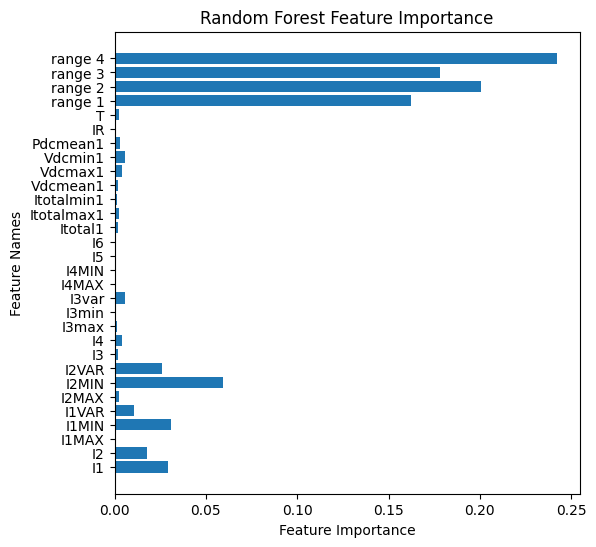

In [52]:
feature_importances = random_forest.feature_importances_
feature_names = X_train.columns

plt.figure(figsize=(6, 6))  

plt.barh(feature_names, feature_importances)
plt.xlabel('Feature Importance')
plt.ylabel('Feature Names')
plt.title('Random Forest Feature Importance')
plt.show()

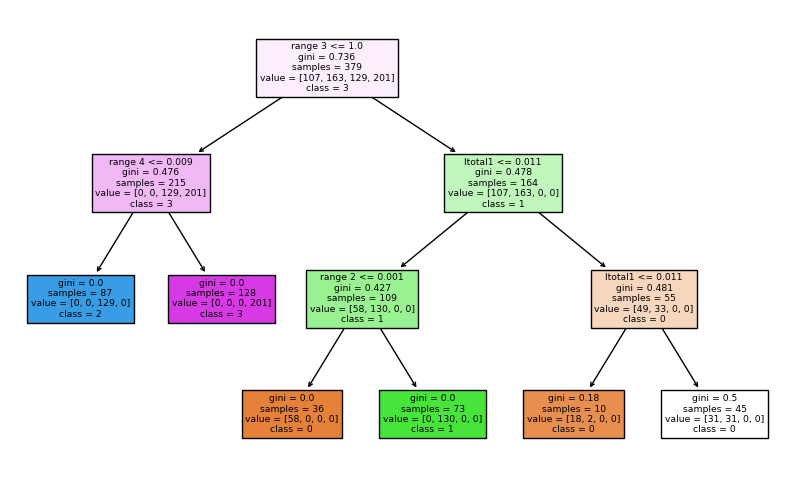

In [53]:
from sklearn.tree import plot_tree

plt.figure(figsize=(10, 6))
plot_tree(random_forest.estimators_[1], feature_names=X_train.columns, class_names=['0', '1', '2', '3'], filled=True)
plt.show()

#### Evaluation on Training Data

In [54]:
y_train_pred_proba = random_forest.predict_proba(X_train_scaled)

# Precision
precision_train = precision_score(y_train, random_forest.predict(X_train_scaled), average='weighted')

# Recall
recall_train = recall_score(y_train, random_forest.predict(X_train_scaled), average='weighted')

# F1-Score
f1_train = f1_score(y_train, random_forest.predict(X_train_scaled), average='weighted')

# Classification Accuracy
accuracy_train = accuracy_score(y_train, random_forest.predict(X_train_scaled))

# Log Loss
log_loss_value_train = log_loss(y_train, y_train_pred_proba)

# Confusion Matrix
conf_matrix_train = confusion_matrix(y_train, random_forest.predict(X_train_scaled))

# AROC Curve
roc_auc_train = roc_auc_score(y_train, y_train_pred_proba, multi_class='ovr', labels=random_forest.classes_)

# Evaluation Metrics
print(f'Training Confusion Matrix:\n{conf_matrix_train}')
print()
print(f'Training Area Under the ROC Curve (AROC): {roc_auc_train}')
print(f'Training Accuracy: {accuracy_train}')
print(f'Training F1-Score: {f1_train}')
print(f'Training Precision: {precision_train}')
print(f'Training Recall: {recall_train}')
print(f'Training Log Loss: {log_loss_value_train}')

Training Confusion Matrix:
[[100   0   0   0]
 [  0 153   0   0]
 [  0   0 149   0]
 [  0   0   0 198]]

Training Area Under the ROC Curve (AROC): 1.0
Training Accuracy: 1.0
Training F1-Score: 1.0
Training Precision: 1.0
Training Recall: 1.0
Training Log Loss: 0.452681423669151


#### Evaluation on Test Data

In [55]:
y_test_pred = random_forest.predict(X_test_scaled)
#y_test_proba = random_forest.predict_proba(X_test_scaled)[:, 1]  
y_test_pred_proba = random_forest.predict_proba(X_test_scaled)

# Precision
precision = precision_score(y_test, y_test_pred, average='weighted')
%store precision

# Recall
recall = recall_score(y_test, y_test_pred, average='weighted')
%store recall

# F1-Score
f1 = f1_score(y_test, y_test_pred, average='weighted')
%store f1

# Classification Accuracy
accuracy = accuracy_score(y_test, y_test_pred)
%store accuracy

# Log Loss
log_loss_value_test = log_loss(y_test, y_test_pred_proba, labels=random_forest.classes_)
%store log_loss_value_test

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_test_pred)
%store conf_matrix

# AROC Curve
roc_auc = roc_auc_score(y_test, y_test_pred_proba, multi_class='ovr', labels=random_forest.classes_)
%store roc_auc

# Evaluation Metrics
print(f'\nTest Confusion Matrix:\n{conf_matrix}')
print(f'\nTest Area Under the ROC Curve (AROC): {roc_auc}')
print(f'Test Accuracy: {accuracy}')
print(f'Test F1-Score: {f1}')
print(f'Test Precision: {precision}')
print(f'Test Recall: {recall}')
print(f'Test Log Loss: {log_loss_value_test}')

Stored 'precision' (float64)
Stored 'recall' (float64)
Stored 'f1' (float64)
Stored 'accuracy' (float64)
Stored 'log_loss_value_test' (float64)
Stored 'conf_matrix' (ndarray)
Stored 'roc_auc' (float64)

Test Confusion Matrix:
[[25  0  0  0]
 [ 4 21  0  0]
 [ 0  9 16  0]
 [ 0  0  0 25]]

Test Area Under the ROC Curve (AROC): 0.9872
Test Accuracy: 0.87
Test F1-Score: 0.8675125236100846
Test Precision: 0.8905172413793103
Test Recall: 0.87
Test Log Loss: 0.6398300752764272


### Plot Results
#### Confusion Matrix

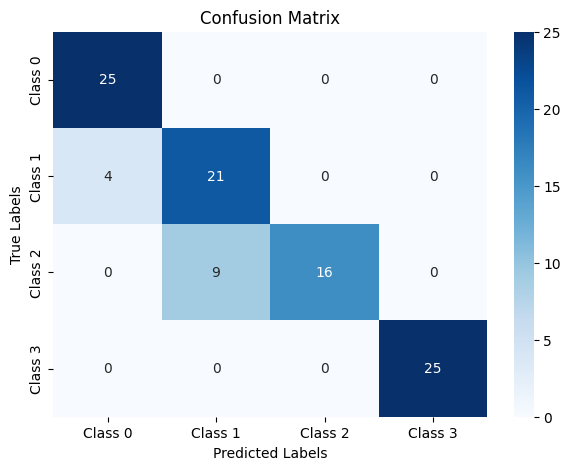

In [56]:
conf_matrix = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrix 
plt.figure(figsize=(7, 5))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', xticklabels=['Class 0', 'Class 1', 'Class 2', 'Class 3'], yticklabels=['Class 0', 'Class 1', 'Class 2', 'Class 3'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

#### Receiver Operating Characteristic (ROC) Curve

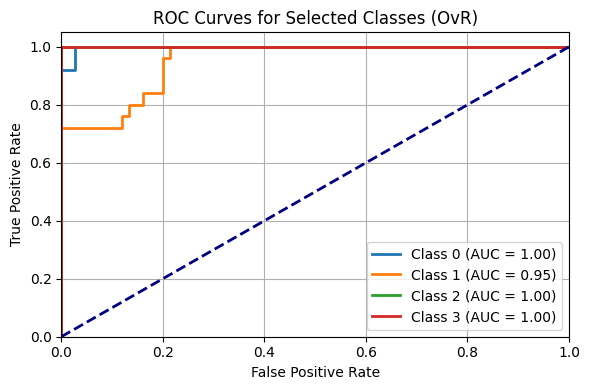

In [57]:
selected_classes = [0, 1, 2, 3]
plt.figure(figsize=(6, 4))

for class_label in selected_classes:
    y_test_binary = (y_test == class_label).astype(int)
    fpr, tpr, thresholds = roc_curve(y_test_binary, y_test_pred_proba[:, class_label])
    roc_auc = auc(fpr, tpr)
    
    # Customize κάθε κλάση
    plt.plot(fpr, tpr, label=f'Class {class_label} (AUC = {roc_auc:.2f})', 
             color=plt.cm.get_cmap('tab10')(class_label), linestyle='-', linewidth=2)

# Plot the diagonal line 
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Selected Classes (OvR)')
plt.legend(loc='lower right')

plt.grid(True)
plt.tight_layout()
plt.show()


#### Precision, Recall, F1 Score, Accuracy

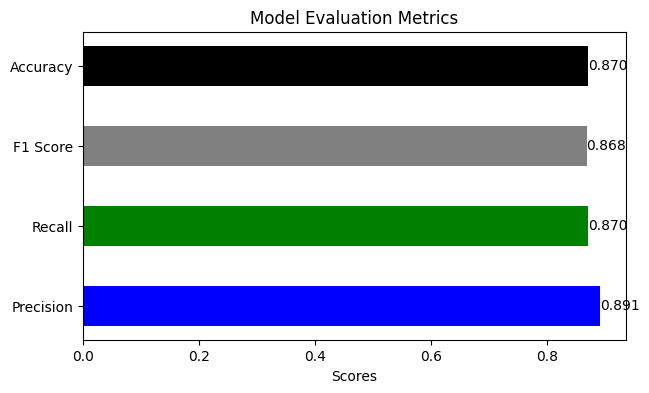

In [58]:
fig, ax = plt.subplots(figsize=(7, 4))
metrics = ['Precision', 'Recall', 'F1 Score', 'Accuracy']
scores = [precision, recall, f1, accuracy]
bar_width = 0.5

# Plot horizontal bars
bars = ax.barh(metrics, scores, height=bar_width, color=['blue', 'green', 'grey', 'black'])

# Display actual values 
for bar in bars:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f'{bar.get_width():.3f}', 
             va='center', ha='left', color='black')

ax.set_xlabel('Scores')
ax.set_title('Model Evaluation Metrics')

plt.show()

#### Log Loss

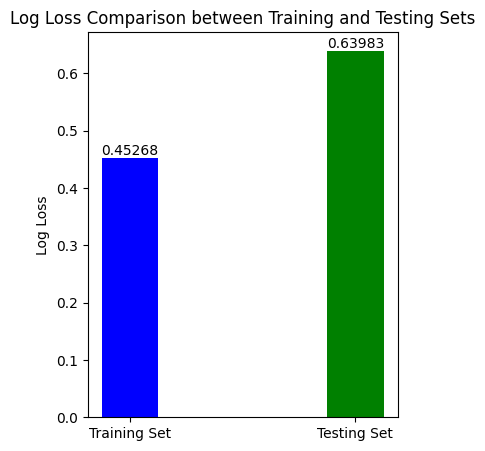

In [59]:
# Plotting
fig, ax = plt.subplots(figsize=(4, 5))

log_loss_values = [log_loss_value_train, log_loss_value_test]
labels = ['Training Set', 'Testing Set']

bar_width = 0.25

ax.bar(labels, log_loss_values, color=['blue', 'green'], width=bar_width)

for bar in ax.patches:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{bar.get_height():.5f}',
             va='bottom', ha='center', color='black')

ax.set_ylabel('Log Loss')
ax.set_title('Log Loss Comparison between Training and Testing Sets')

plt.show()

#### Random Forest Algorithm with 5fold Cross Validation

In [60]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
rf_5cross = RandomForestClassifier(random_state=42)

scoring_metrics = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'neg_log_loss', 'roc_auc_ovo_weighted']

cv_results = cross_validate(rf_5cross, X_dataset, y_dataset, cv=kf, scoring=scoring_metrics, return_train_score=False)

for fold in range(1, kf.get_n_splits() + 1):
    print(f"Fold {fold} Metrics:")
    print(f"Accuracy: {cv_results['test_accuracy'][fold-1]}")
    print(f"Precision: {cv_results['test_precision_weighted'][fold-1]}")
    print(f"Recall: {cv_results['test_recall_weighted'][fold-1]}")
    print(f"F1 Score: {cv_results['test_f1_weighted'][fold-1]}")
    print(f"Log Loss: {abs(np.mean(cv_results['test_neg_log_loss'][fold-1]))}")
    print(f"ROC AUC: {cv_results['test_roc_auc_ovo_weighted'][fold-1]}")
    print("--"*100)

mean_metrics = {metric: np.mean(cv_results[f'test_{metric}']) for metric in scoring_metrics}

print("Mean Metrics Across Folds:")
for metric, value in mean_metrics.items():
    if metric == 'neg_log_loss':
        value = abs(value)
    print(f"{metric}: {value}")

Fold 1 Metrics:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Log Loss: 0.06831609964704488
ROC AUC: 1.0
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Fold 2 Metrics:
Accuracy: 0.9928571428571429
Precision: 0.993045112781955
Recall: 0.9928571428571429
F1 Score: 0.9928287740628167
Log Loss: 0.08757199487913528
ROC AUC: 1.0
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Fold 3 Metrics:
Accuracy: 0.9857142857142858
Precision: 0.9867724867724869
Recall: 0.9857142857142858
F1 Score: 0.9857657967032968
Log Loss: 0.09807266052044206
ROC AUC: 1.0
-----------------------------------------------------------------------------------------------------------------------------------------

##### Plot the Cross Valdation Results

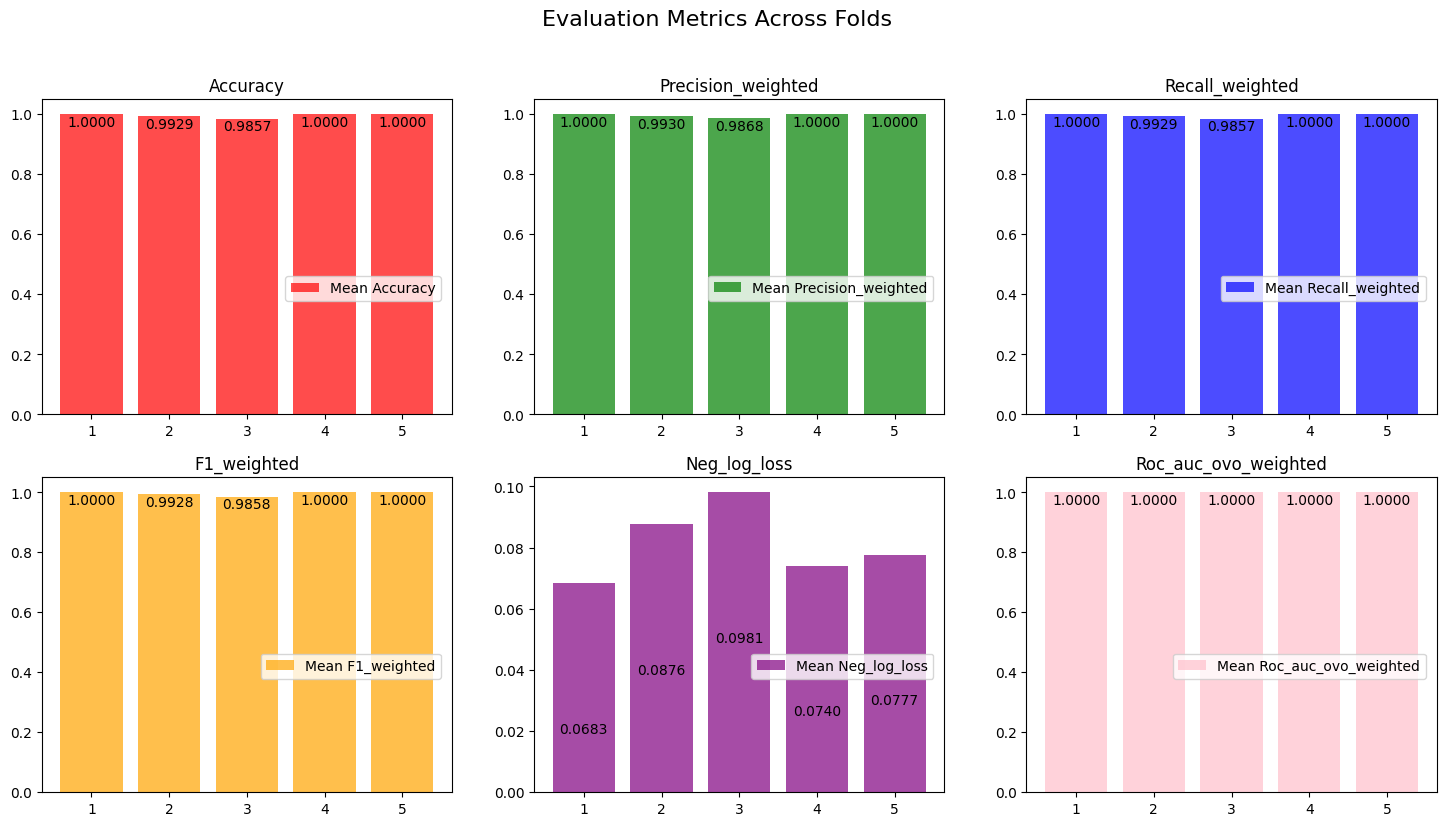

In [61]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 9))
fig.suptitle('Evaluation Metrics Across Folds', fontsize=16)

# Function για τς τιμές μέσα στις μπάρες
def add_values(ax, values):
    for i, value in enumerate(values):
        ax.text(i + 1, value - 0.05, f'{value:.4f}', ha='center', va='bottom', color='black')

bar_height = 0.5
metrics_to_plot = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'neg_log_loss', 'roc_auc_ovo_weighted']
colors = ['red', 'green', 'blue', 'orange', 'purple', 'pink']  

for idx, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    row = idx // 3
    col = idx % 3

    if metric == 'neg_log_loss':
        metric_values = np.abs(cv_results[f'test_{metric}'])
    else:
        metric_values = cv_results[f'test_{metric}']

    bars = axes[row, col].bar(range(1, kf.get_n_splits() + 1), metric_values, color=color, alpha=0.7)
    axes[row, col].set_title(metric.capitalize())
    add_values(axes[row, col], metric_values)

    axes[row, col].legend([f'Mean {metric.capitalize()}'], loc='center right', bbox_to_anchor=(0.99, 0.4))

if len(metrics_to_plot) < 6:
    fig.delaxes(axes[-1, -1])

plt.subplots_adjust(hspace=0.2)
plt.show()